# ***ARYAN KHAN | 17 | 221A036***

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [12]:
class MultiArmedBandit:
  def __init__(self, k=10):
    self.k = k
    self.q_true = np.random.normal(0, 1, k)
    self.best_arm = np.argmax(self.q_true)

  def pull_arm(self, arm):
    return np.random.normal(self.q_true[arm], 1)

In [13]:
class Agent:
  def __init__(self, bandit, strategy = "epsilon_greedy", epsilon = 0.1, c=2):
    self.bandit = bandit
    self.strategy = strategy
    self.epsilon = epsilon
    self.c = c
    self.k = bandit.k
    self.Q = np.zeros(self.k)
    self.N = np.zeros(self.k)


  def select_action(self, t):
    if self.strategy == "epsilon_greedy":
      if np.random.rand() < self.epsilon:
        return np.random.randint(self.k)
      return np.argmax(self.Q)

    elif self.strategy == "ucb1":
      if 0 in self.N:
        return np.argmin(self.N)
      return np.argmax(self.Q + self.c * np.sqrt(np.log(t+1)/self.N))


  def update(self, arm, reward):
    self.N[arm] += 1
    self.Q[arm] += (reward - self.Q[arm])/self.N[arm]


In [14]:
def run_strategy(k = 10, steps=1000, runs=200, strategies=["epsilon_greedy", "ucb1"]):
  avg_rewards = {strategy: np.zeros(steps) for strategy in strategies}


  for strategy in strategies:
    for run in range(runs):
      bandit = MultiArmedBandit(k)
      agent = Agent(bandit, strategy=strategy)

      rewards = np.zeros(steps)
      for t in range(steps):
        action = agent.select_action(t)
        reward = bandit.pull_arm(action)
        agent.update(action, reward)
        rewards[t] = reward
      avg_rewards[strategy] += rewards / runs
  return avg_rewards

In [15]:
strategies = ["epsilon_greedy", "ucb1"]
results = run_strategy()

In [16]:
results.keys()

dict_keys(['epsilon_greedy', 'ucb1'])

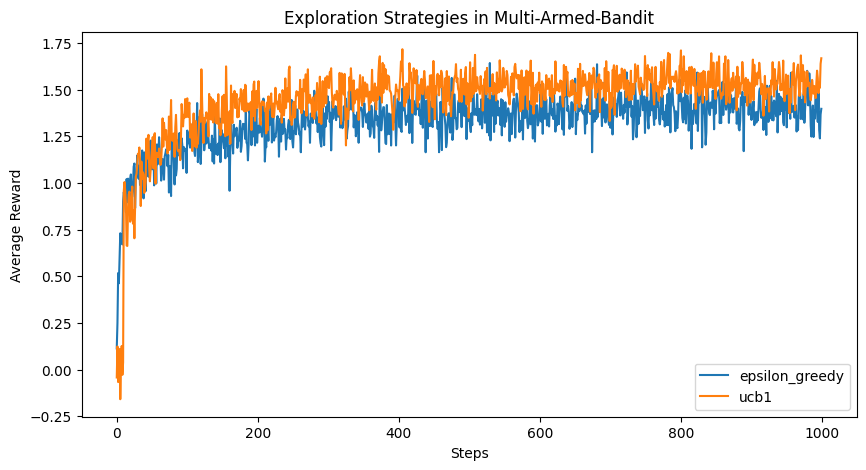

In [17]:
plt.figure(figsize=(10,5))
for strategy, rewards in results.items():
  plt.plot(rewards, label=strategy)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.title("Exploration Strategies in Multi-Armed-Bandit")
plt.show()

**Observations**

**Initial Phase(First 100 Steps)**
Both Strategies start with low rewards and improve over time .
UCB1 shows a faster initial learning rate, meaning it finds better arms more quickly.

**Middle Phase(100-500 Steps)**
UCB1 consistently outperforms Epsilon-Greedy with slightly higher rewards
Epsilon-Greedy fluctuates more, as it keeps exploring randomly with probability e

**Final Phase(500-1000 Steps)**
UCB1 stabilizes at a slightly higher average reward

**Conclusion**
For short duration either of the algorithm can be used

But for long duration UCB1 must be used




